# RNN — TensorFlow Pipeline

## Model: Recurrent Neural Network (Vanilla RNN + GRU)
- **Dataset**: ECG5000 — 4,000 train / 1,000 test, 140 timesteps, 5 heartbeat classes
- **Task**: Classify heartbeat arrhythmias (severe class imbalance: 121.6x ratio)
- **Framework showcase**: Keras Sequential API (SimpleRNN/GRU layers), model.fit with class_weight, GradientTape for gradient analysis
- **Device**: CPU (Windows) — ECG5000 trains in seconds, WSL2 GPU unnecessary

## Evaluation Strategy
- **Primary metric**: Macro F1 (not accuracy — 58% majority class makes accuracy misleading)
- **Training curves**: Loss + accuracy (train/val)
- **Gradient analysis**: Per-layer gradient norms comparing vanilla RNN vs GRU

## Pipeline
1. Load data + config
2. Vanilla RNN baseline
3. Vanishing gradient demonstration
4. GRU model (gated fix)
5. Architecture sweep (hidden size, depth, bidirectional)
6. Best model full evaluation
7. Benchmarks
8. Save results + cross-framework comparison

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import time
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.visualization import (plot_training_history,
                                  plot_confusion_matrix_multiclass,
                                  plot_gradient_flow,
                                  plot_ecg_predictions,
                                  plot_hidden_state_evolution)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison
from utils.rnn_utils import compute_gradient_norms

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "RNN"
BATCH_SIZE = 64
N_CLASSES = 5
N_FEATURES = 1
SEQ_LEN = 140

tf.random.set_seed(RANDOM_STATE)

# Detect device
gpus = tf.config.list_physical_devices('GPU')
device_name = gpus[0].name if gpus else "CPU"

# Load data
X_train, X_test, y_train, y_test, metadata = load_processed_data('rnn')

CLASS_NAMES = metadata['class_names']
class_weights = {int(k): v for k, v in metadata['class_weights'].items()}

# Ensure float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Results directory
os.makedirs('results', exist_ok=True)

# Step 1:
print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: {'GPU' if gpus else 'CPU'} ({device_name})")
print(f"TF version: {tf.__version__}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Sequence: {SEQ_LEN} timesteps x {N_FEATURES} feature")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"Batch size: {BATCH_SIZE}")
print(f"Class weights: {[f'{v:.2f}' for v in class_weights.values()]}")

[1/8] TensorFlow — RNN Pipeline
Device: CPU (CPU)
TF version: 2.20.0
Train: (4000, 140, 1) | Test: (1000, 140, 1)
Sequence: 140 timesteps x 1 feature
Classes: 5 (Normal, R-on-T PVC, PVC, SP, UB)
Batch size: 64
Class weights: ['0.34', '0.57', '10.39', '5.16', '42.11']


In [2]:
# Step 2: Vanilla RNN Baseline
"""
keras.layers.SimpleRNN — Keras equivalent of nn.RNN.
Uses model.fit() with class_weight dict for imbalanced data.
EarlyStopping on val macro F1 via custom callback.
Expect similar results to PT: ~85% accuracy, ~0.49 macro F1.
"""

print("=" * 60)
print("[2/8] Vanilla RNN — Baseline")
print("=" * 60)


class MacroF1Callback(keras.callbacks.Callback):
    """
    Track validation macro F1 for early stopping.

    Keras EarlyStopping only monitors built-in metrics.
    This callback computes macro F1 each epoch and stores
    the best model weights.

    Args:
        X_val: Validation input array.
        y_val: Validation labels.
        patience: Epochs to wait after best F1.
    """
    def __init__(self, X_val, y_val, patience=10):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience
        self.best_f1 = 0.0
        self.wait = 0
        self.best_weights = None
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1 = float(macro_f1_score(self.y_val, preds))
        self.val_f1s.append(f1)

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True


# Train/val split (same 10% as PT, seeded)
np.random.seed(RANDOM_STATE)
n_val = int(len(X_train) * 0.1)
perm = np.random.permutation(len(X_train))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

# Build vanilla RNN
vanilla_rnn = keras.Sequential([
    keras.layers.SimpleRNN(64, return_sequences=True,
                            input_shape=(SEQ_LEN, N_FEATURES)),
    keras.layers.SimpleRNN(64),
    keras.layers.Dense(N_CLASSES)
])

vanilla_rnn.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

n_params_vanilla = vanilla_rnn.count_params()
print(f"Architecture: SimpleRNN(64) x2 -> Dense(5)")
print(f"Parameters: {n_params_vanilla:,}")

# Train
f1_cb = MacroF1Callback(X_val, y_val, patience=10)

with track_performance() as perf_vanilla:
    hist_vanilla_raw = vanilla_rnn.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[f1_cb],
        verbose=0
    )

# Restore best weights
vanilla_rnn.set_weights(f1_cb.best_weights)

# Convert Keras history to our standard format
hist_vanilla = {
    'train_loss': hist_vanilla_raw.history['loss'],
    'val_loss': hist_vanilla_raw.history['val_loss'],
    'train_acc': hist_vanilla_raw.history['accuracy'],
    'val_acc': hist_vanilla_raw.history['val_accuracy'],
    'val_f1': f1_cb.val_f1s,
    'epochs': len(hist_vanilla_raw.history['loss']),
    'best_val_f1': f1_cb.best_f1
}

# Test evaluation
vanilla_preds = np.argmax(vanilla_rnn.predict(X_test, verbose=0), axis=1)
vanilla_metrics = evaluate_classifier(y_test, vanilla_preds)
vanilla_f1, vanilla_per_class = macro_f1_score(y_test, vanilla_preds, return_per_class=True)

print(f"\nEpochs: {hist_vanilla['epochs']} | Best val F1: {hist_vanilla['best_val_f1']:.4f}")
print(f"Training time: {perf_vanilla['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {vanilla_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {vanilla_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, vanilla_per_class)):
    print(f"  {name:<15} F1={f1:.4f} (n={np.sum(y_test == i)})")

[2/8] Vanilla RNN — Baseline
Architecture: SimpleRNN(64) x2 -> Dense(5)
Parameters: 12,805


c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epochs: 26 | Best val F1: 0.5194
Training time: 29.61s

Test Results:
  Accuracy:  0.8720
  Macro F1:  0.5207

Per-class F1:
  Normal          F1=0.9510 (n=584)
  R-on-T PVC      F1=0.9083 (n=353)
  PVC             F1=0.3385 (n=19)
  SP              F1=0.3059 (n=39)
  UB              F1=0.1000 (n=5)


[3/8] Vanishing Gradient Demonstration
Vanilla RNN — Gradient Norms (L2):
--------------------------------------------------
  kernel                                   6.532087e-01
  recurrent_kernel                         7.886039e-01
  bias                                     1.660973e-01

Gradient range: 6.53e-01 -> 7.89e-01
Max/min ratio: 1.2x


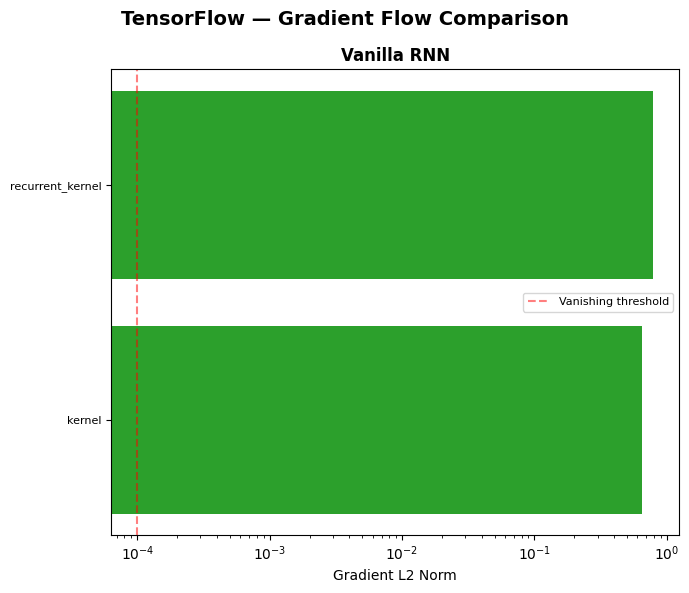

In [3]:
# Step 3: Vanishing Gradient Demonstration
"""
compute_gradient_norms with framework='tensorflow' uses GradientTape.
Same analysis as PT: measure per-layer gradient L2 norms.
Expect healthy gradients on 140-step sequences (same as PT finding).
"""

print("=" * 60)
print("[3/8] Vanishing Gradient Demonstration")
print("=" * 60)

# Small batch for gradient computation
grad_batch_x = X_train[:64]
grad_batch_y = y_train[:64]

# Loss function for gradient computation
grad_loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compute gradient norms
vanilla_grads = compute_gradient_norms(
    vanilla_rnn, grad_loss_fn, grad_batch_x, grad_batch_y, framework='tensorflow'
)

print("Vanilla RNN — Gradient Norms (L2):")
print("-" * 50)
for name, norm in vanilla_grads.items():
    tag = " <- VANISHING" if norm < 1e-4 else ""
    print(f"  {name:<40} {norm:.6e}{tag}")

# Summary stats
weight_grads = {k: v for k, v in vanilla_grads.items()
                if 'kernel' in k.lower() or 'weight' in k.lower()}
if not weight_grads:
    weight_grads = vanilla_grads

min_grad = min(weight_grads.values())
max_grad = max(weight_grads.values())
ratio = max_grad / min_grad if min_grad > 0 else float('inf')

print(f"\nGradient range: {min_grad:.2e} -> {max_grad:.2e}")
print(f"Max/min ratio: {ratio:.1f}x")

# Plot — vanilla RNN only for now (GRU added after Cell 4)
plot_gradient_flow({'Vanilla RNN': vanilla_grads}, framework='TensorFlow',
                   save_path='results/gradient_flow_vanilla.png')